In [1]:
from resources.imports import *

from resources.lattices import Geometry, pStrainProperties, effProperties
from resources.MLdata import DATA, load_data, prep_UTdata, prep_FTdata, prep_FCLdata, remove_outliers, split_data, \
                             save_MLdata, plot_sampling, locSims, get_stats, plot_frequency, plot_properties, plot_curve

In [2]:
### Global Inputs

mode = ("compare", "Target-xs")

DAT = DATA(path=1, 
           path_add="",
           LAT="FCC", 
           dis="disNodes", 
           dN=0.2)

if mode is not None:
    if mode[0].lower() == "compare":
        DAT = DATA(path=1, 
           path_add="",
           LAT=DAT.LAT, 
           dis=DAT.dis, 
           dN=DAT.dN)
        
        DATc = DATA(path=1, 
           path_add=mode[1],
           LAT=DAT.LAT, 
           dis=DAT.dis, 
           dN=DAT.dN)

l = 0.010
if DAT.LAT.lower() == "fcc":
    nnx = 20
    MODEL = "both"
    manual_outliersUT = None
    manual_outliersFT = None
elif DAT.LAT.lower() == "kagome":
    nnx = 20
    MODEL = "both"
    manual_outliersUT = None
    manual_outliersFT = None
elif DAT.LAT.lower() == "hex":
    nnx = 20
    MODEL = "both"
    manual_outliersUT = None
    manual_outliersFT = [175]
elif DAT.LAT.lower() == "tri":
    nnx = 30
    MODEL = "both"
    manual_outliersUT = None
    manual_outliersFT = None

MODEL = MODEL      # ductile, fracture, both

# Load Data

In [3]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    DAT.UT_CSVin  = DAT.PATH + f'Ductile-{DAT.dis}-IN.csv'
    DAT.UT_CSVout = DAT.PATH + f'Ductile-{DAT.dis}-OUT.csv'
    DAT.UT_CSVin_f = None
    if DAT.freq:
        DAT.UT_CSVin_f = DAT.PATH + f'Ductile-{DAT.dis}-INf.csv'

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    DAT.FT_CSVin  = DAT.PATH + f'Fracture-{DAT.dis}-IN.csv'
    DAT.FT_CSVout = DAT.PATH + f'Fracture-{DAT.dis}-OUT.csv'
    DAT.FT_CSVin_f = None
    if DAT.freq:
        DAT.FT_CSVin_f = DAT.PATH + f'Fracture-{DAT.dis}-INf.csv'

if mode is not None and mode[0].lower() == "compare":
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        DATc.UT_CSVin  = DATc.PATH + f'Ductile-{DATc.dis}-IN.csv'
        DATc.UT_CSVout = DATc.PATH + f'Ductile-{DATc.dis}-OUT.csv'
        DATc.UT_CSVin_f = None
        if DATc.freq:
            DATc.UT_CSVin_f = DATc.PATH + f'Ductile-{DATc.dis}-INf.csv'

    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        DATc.FT_CSVin  = DATc.PATH + f'Fracture-{DATc.dis}-IN.csv'
        DATc.FT_CSVout = DATc.PATH + f'Fracture-{DATc.dis}-OUT.csv'
        DATc.FT_CSVin_f = None
        if DATc.freq:
            DATc.FT_CSVin_f = DATc.PATH + f'Fracture-{DATc.dis}-INf.csv'

In [4]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_INf_df, DAT.UT_perINr_df, DAT.UT_perIN_df, DAT.UT_perOUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df = load_data(DAT.UT_CSVin, DAT.UT_CSVout, DAT.UT_CSVin_f)

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_INf_df, DAT.FT_perINr_df, DAT.FT_perIN_df, DAT.FT_perOUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df = load_data(DAT.FT_CSVin, DAT.FT_CSVout, DAT.FT_CSVin_f)

if mode is not None and mode[0].lower() == "compare":
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_INf_df, DATc.UT_perINr_df, DATc.UT_perIN_df, DATc.UT_perOUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df = load_data(DATc.UT_CSVin, DATc.UT_CSVout, DATc.UT_CSVin_f)

    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_INf_df, DATc.FT_perINr_df, DATc.FT_perIN_df, DATc.FT_perOUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df = load_data(DATc.FT_CSVin, DATc.FT_CSVout, DATc.FT_CSVin_f)

# Geometry

In [5]:
geom = Geometry(DAT.LAT, l, nnx)
geom.FTcalc()

E = 123e9  ## Pa
v = 0.3
rD = 0.2
E_eff, v_eff, E_eff_pe, v_eff_pe = effProperties(DAT.LAT, E, rD)

# Prep Data

In [6]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    DAT.UT_dIN_r, DAT.UT_dOUT_r, DAT.UT_INf_r, DAT.UT_xOUT, DAT.UT_props_r, DAT.UT_props_r_df = prep_UTdata(DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_perOUT_df, DAT.UT_OUT_df, DAT.UT_INf_df)
    DAT.UT_dIN, DAT.UT_dOUT, DAT.UT_INf, DAT.UT_props, DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_props_df, DAT.UT_INf_df = remove_outliers(DAT.UT_dIN_r, DAT.UT_dOUT_r, DAT.UT_props_r, DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_props_r_df, DAT.UT_INf_r, DAT.UT_INf_df, manual=manual_outliersUT)
    DAT.UT_train, DAT.UT_val, DAT.UT_test = split_data(DAT.UT_dIN[1:], DAT.UT_dOUT[1:], DAT.UT_props, DAT.UT_INf, split=0.85)
    save_MLdata(DAT.UT_perIN_df, DAT.UT_perOUT_df, DAT.UT_train, DAT.UT_val, DAT.UT_test, DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_INf_df, DAT.UT_props_df, DAT.PATH, "UT", DAT.dis)

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    DAT.FT_dIN_r, DAT.FT_dOUT_r, DAT.FT_INf_r, DAT.FT_xOUT, DAT.FT_props_r, DAT.FT_props_r_df = prep_FTdata(DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_perOUT_df, DAT.FT_OUT_df, geom, E_eff_pe, DAT.FT_INf_df)
    DAT.FT_dIN, DAT.FT_dOUT, DAT.FT_INf, DAT.FT_props, DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_props_df, DAT.FT_INf_df = remove_outliers(DAT.FT_dIN_r, DAT.FT_dOUT_r, DAT.FT_props_r, DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_props_r_df, DAT.FT_INf_r, DAT.FT_INf_df, manual=manual_outliersFT)
    DAT.FT_train, DAT.FT_val, DAT.FT_test = split_data(DAT.FT_dIN[1:], DAT.FT_dOUT[1:], DAT.FT_props, DAT.FT_INf, split=0.85)
    save_MLdata(DAT.FT_perIN_df, DAT.FT_perOUT_df, DAT.FT_train, DAT.FT_val, DAT.FT_test, DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_INf_df, DAT.FT_props_df, DAT.PATH, "FT", DAT.dis)

if MODEL.lower() == "both":
    DAT.common_props_df = prep_FCLdata(DAT.UT_props_df, DAT.FT_props_df, E_eff_pe)
    
    
if mode is not None and mode[0].lower() == "compare":
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        DATc.UT_dIN_r, DATc.UT_dOUT_r, DATc.UT_INf_r, DATc.UT_xOUT, DATc.UT_props_r, DATc.UT_props_r_df = prep_UTdata(DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_perOUT_df, DATc.UT_OUT_df, DATc.UT_INf_df)
        DATc.UT_dIN, DATc.UT_dOUT, DATc.UT_INf, DATc.UT_props, DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_props_df, DATc.UT_INf_df = remove_outliers(DATc.UT_dIN_r, DATc.UT_dOUT_r, DATc.UT_props_r, DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_props_r_df, DATc.UT_INf_r, DATc.UT_INf_df, manual=manual_outliersFT)
        DATc.UT_train, DATc.UT_val, DATc.UT_test = split_data(DATc.UT_dIN[1:], DATc.UT_dOUT[1:], DATc.UT_props, DATc.UT_INf, split=0.85)
        save_MLdata(DATc.UT_perIN_df, DATc.UT_perOUT_df, DATc.UT_train, DATc.UT_val, DATc.UT_test, DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_INf_df, DATc.UT_props_df, DATc.PATH, "UT", DATc.dis)
    
    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        DATc.FT_dIN_r, DATc.FT_dOUT_r, DATc.FT_INf_r, DATc.FT_xOUT, DATc.FT_props_r, DATc.FT_props_r_df = prep_FTdata(DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_perOUT_df, DATc.FT_OUT_df, geom, E_eff_pe, DATc.FT_INf_df)
        DATc.FT_dIN, DATc.FT_dOUT, DATc.FT_INf, DATc.FT_props, DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_props_df, DATc.FT_INf_df = remove_outliers(DATc.FT_dIN_r, DATc.FT_dOUT_r, DATc.FT_props_r, DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_props_r_df, DATc.FT_INf_r, DATc.FT_INf_df, manual=manual_outliersFT)
        DATc.FT_train, DATc.FT_val, DATc.FT_test = split_data(DATc.FT_dIN[1:], DATc.FT_dOUT[1:], DATc.FT_props, DATc.FT_INf, split=0.85)
        save_MLdata(DATc.FT_perIN_df, DATc.FT_perOUT_df, DATc.FT_train, DATc.FT_val, DATc.FT_test, DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_INf_df, DATc.FT_props_df, DATc.PATH, "FT", DATc.dis)

    if MODEL.lower() == "both":
        DATc.common_props_df = prep_FCLdata(DATc.UT_props_df, DATc.FT_props_df, E_eff_pe)

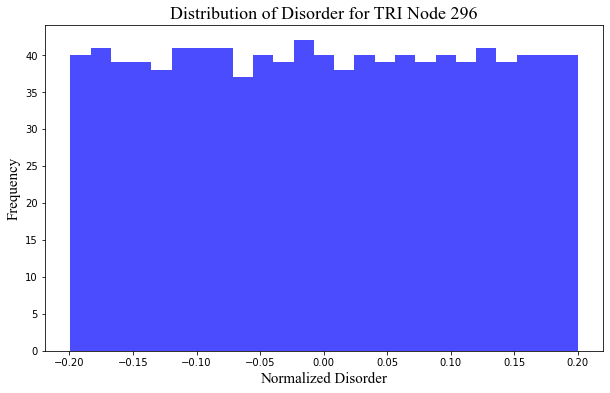

In [8]:
plot_sampling(DAT.UT_dIN_df, DAT.LAT, l, indx=None, num=1, by="Node")

In [9]:
DAT.common_props_df

,Ductility,Strength,Stiffness,WoF,K_JIC,K_IC,Force,Displacement,FCL
0,0.065502,75.241507,8660.150270,4.521011,4.687302e+07,3.380943e+07,165838.340625,0.010228,0.058475
1,0.038501,68.314209,8299.187400,2.108385,3.071936e+07,2.637526e+07,129373.065625,0.006179,0.053856
2,0.038001,69.565274,8305.744987,2.301754,3.976392e+07,3.032159e+07,148730.187500,0.008630,0.082656
3,0.040501,67.257611,8320.304083,1.988616,4.146678e+07,3.015432e+07,147909.701250,0.009482,0.104041
4,0.037001,67.844355,8318.337431,1.952535,4.233329e+07,3.084582e+07,151301.575625,0.009482,0.110439
...,...,...,...,...,...,...,...,...,...
996,0.039501,67.697633,8343.525515,2.168911,3.883879e+07,2.973563e+07,145855.980000,0.008523,0.083685
997,0.032001,67.588198,8287.630446,1.732721,3.308825e+07,2.797886e+07,137238.853750,0.006819,0.076028
998,0.039001,68.946418,8293.324033,2.136084,3.480750e+07,2.918186e+07,143139.710000,0.007245,0.068247
999,0.034001,67.776125,8290.844911,1.960960,3.374553e+07,2.688743e+07,131885.296875,0.007245,0.069875


In [10]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    DAT.UT_stats = get_stats(DAT.UT_props_df)
    DAT.UT_nSims = locSims(DAT.UT_props_df)
    print("FINAL UT SIMULATION COUNT:", len(DAT.UT_OUT_df)-1)
    print(f"{pd.concat([DAT.UT_stats, DAT.UT_nSims])}\n\n")
    print(f"{(DAT.UT_stats-DAT.UT_props_df.iloc[0])/DAT.UT_props_df.iloc[0]}\n\n")

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    DAT.FT_stats = get_stats(DAT.FT_props_df)
    DAT.FT_nSims = locSims(DAT.FT_props_df)
    print("FINAL FT SIMULATION COUNT:", len(DAT.FT_OUT_df)-1)
    print(f"{pd.concat([DAT.FT_stats, DAT.FT_nSims])}\n\n")

if mode is not None and mode[0].lower() == "compare":
    print("\n=============== COMPARISON DATA ===============\n")
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        DATc.UT_stats = get_stats(DATc.UT_props_df)
        DATc.UT_nSims = locSims(DATc.UT_props_df)
        print("FINAL UT SIMULATION COUNT:", len(DATc.UT_OUT_df)-1)
        print(f"{pd.concat([DATc.UT_stats, DATc.UT_nSims])}\n\n")
        print(f"{(DATc.UT_stats-DATc.UT_props_df.iloc[0])/DATc.UT_props_df.iloc[0]}\n\n")


    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        DATc.FT_stats = get_stats(DATc.FT_props_df)
        DATc.FT_nSims = locSims(DATc.FT_props_df)
        print("FINAL FT SIMULATION COUNT:", len(DATc.FT_OUT_df)-1)
        print(f"{pd.concat([DATc.FT_stats, DATc.FT_nSims])}\n\n")

FINAL UT SIMULATION COUNT: 992
       Ductility    Strength    Stiffness         WoF
Mean    0.037929   68.291748  8300.541753    2.097734
Std     0.003011    0.733834    27.894076    0.181641
Max   288.000000  739.000000   494.000000  624.000000
Min    23.000000  863.000000   213.000000  561.000000


      Ductility  Strength  Stiffness       WoF
Mean  -0.420948 -0.092366  -0.041525 -0.536003
Std   -0.954038 -0.990247  -0.996779 -0.959823


FINAL FT SIMULATION COUNT: 987
             K_JIC          K_IC          Force  Displacement
Mean  3.778853e+07  2.916966e+07  143079.875429      0.008240
Std   5.077027e+06  1.900753e+06    9323.368816      0.001456
Max   4.360000e+02  8.860000e+02     886.000000    436.000000
Min   4.290000e+02  7.650000e+02     765.000000    429.000000



=============== COMPARISON DATA ===============

FINAL UT SIMULATION COUNT: 992
       Ductility    Strength    Stiffness         WoF
Mean    0.038470   63.388869  8591.900880    2.031994
Std     0.002552    0.

In [11]:
# FT_OUT_df.index.get_loc(FT_OUT_df[FT_OUT_df.index == 182].index[0])

# Plot Distribution & Identify Max, Min Simulations

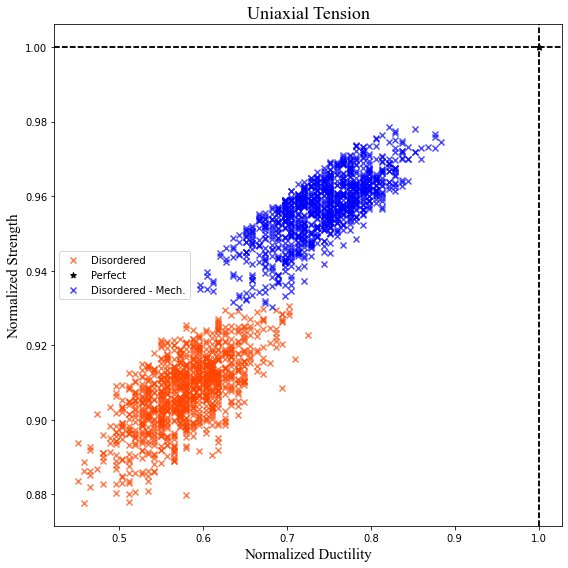

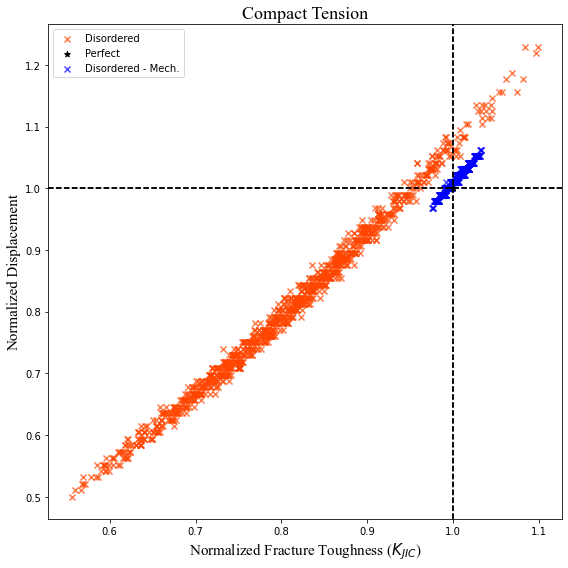

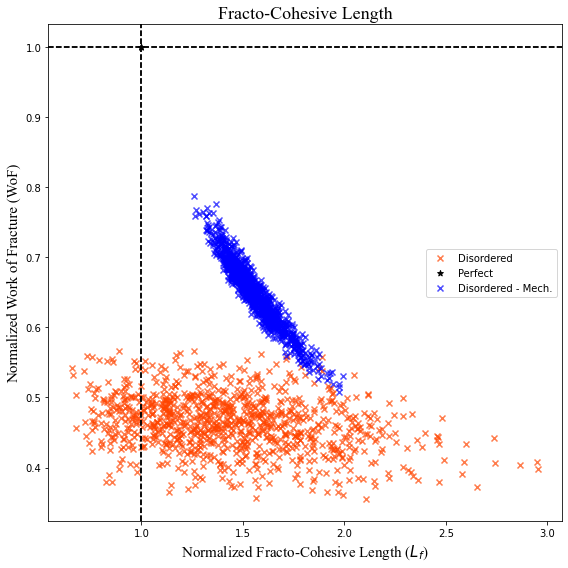

In [12]:
plot_props = True
plot_freq = False
plot_ONLY_freq = False

if plot_props:
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        fig, ax = plot_properties(DAT.UT_props_df["Ductility"], DAT.UT_props_df["Strength"], "UT", include_freq=plot_freq, compare_ax=None)
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.UT_props_df["Ductility"], DATc.UT_props_df["Strength"], "UT", include_freq=plot_freq, compare_ax=(fig, ax))
    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        fig, ax = plot_properties(DAT.FT_props_df["K_JIC"], DAT.FT_props_df["Displacement"], "FT", include_freq=plot_freq, compare_ax=None)
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.FT_props_df["K_JIC"], DATc.FT_props_df["Displacement"], "FT", include_freq=plot_freq, compare_ax=(fig, ax))
    if MODEL.lower() == "both":
        fig, ax = plot_properties(DAT.common_props_df["FCL"], DAT.common_props_df["WoF"], "FCL", include_freq=plot_freq, compare_ax=None)
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.common_props_df["FCL"], DATc.common_props_df["WoF"], "FCL", include_freq=plot_freq, compare_ax=(fig, ax))

if plot_ONLY_freq:
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        plot_frequency(DAT.UT_props_r_df["Ductility"], DAT.UT_props_df["Ductility"], "UT", bins=30)
    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        plot_frequency(DAT.FT_props_r_df["K_JIC"], DAT.FT_props_df["K_JIC"], "FT", bins=30)
    if MODEL.lower() == "both":
        plot_frequency(DAT.common_props_df["FCL"], DAT.common_props_df["FCL"], "FCL", bins=30)

# Plots UT and FT Curves

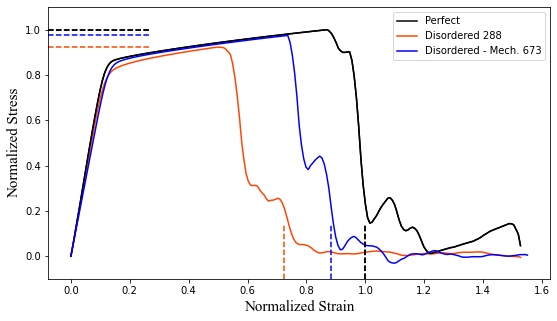

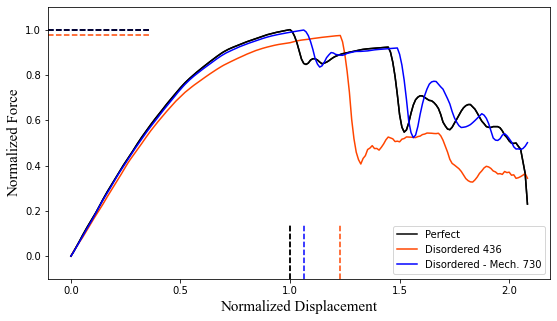

In [13]:
# [UT_nSim_max1, UT_nSim_min1, UT_nSim_max2, UT_nSim_min2, UT_nSim_max3, UT_nSim_min3, UT_nSim_max12, UT_nSim_min12]
# [FT_nSim_max1, FT_nSim_min1, FT_nSim_max2, FT_nSim_min2, FT_nSim_max3, FT_nSim_min3, FT_nSim_max13, FT_nSim_min13]
idx = None
q   = "all"
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    fig2, ax1 = plot_curve(DAT.UT_OUT_df, DAT.UT_xOUT, "ut", pi=0, idx=[DAT.UT_nSims["Ductility"].loc["Max"]], q='all', compare_ax=None)
    if mode is not None and mode[0].lower() == "compare":
        fig2, ax1 = plot_curve(DATc.UT_OUT_df, DATc.UT_xOUT, "ut", pi=0, idx=[DATc.UT_nSims["Ductility"].loc["Max"]], q='all', compare_ax=(fig2, ax1))
    
if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    fig2, ax1 = plot_curve(DAT.FT_OUT_df, DAT.FT_xOUT, "ft", pi=0, idx=[DAT.FT_nSims["K_JIC"].loc["Max"]], q='all', compare_ax=None)
    if mode is not None and mode[0].lower() == "compare":
        fig2, ax1 = plot_curve(DATc.FT_OUT_df, DATc.FT_xOUT, "ft", pi=0, idx=[DATc.FT_nSims["K_JIC"].loc["Max"]], q='all', compare_ax=(fig2, ax1))